  CHME 212 Midterm 2 — Score Summary
  N       : 33
  Mean    : 67.9
  Median  : 68.0
  Std dev : 18.4
  Min/Max : 36 / 100
  Q1/Q3   : 56.0 / 82.0
  IQR     : 26.0
------------------------------------------
  Grade distribution:
    A: █████ 5
    B: ████ 4
    C: ███ 3
    D: █████████ 9
    F: ████████████ 12


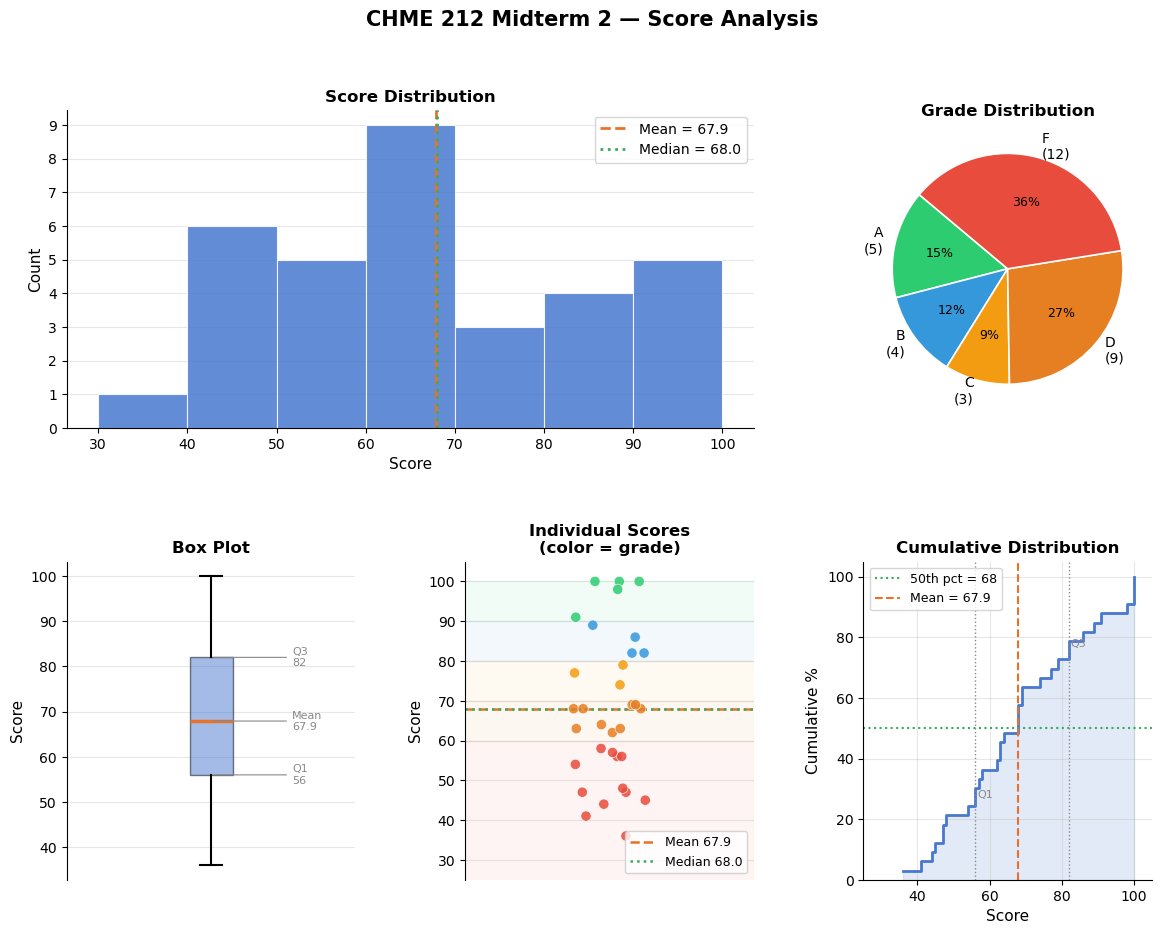

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

scores = np.array([100, 89, 63, 77, 82, 100, 56, 47, 57, 68,
                   69, 68, 86, 91, 36, 41, 69, 62, 100, 44,
                   54, 47, 56, 74, 98, 58, 45, 82, 48, 63,
                   79, 64, 68])

n       = len(scores)
mean    = np.mean(scores)
median  = np.median(scores)
std     = np.std(scores, ddof=1)
lo, hi  = np.min(scores), np.max(scores)
q1, q3  = np.percentile(scores, 25), np.percentile(scores, 75)

# Letter grade bins
def letter(s):
    if s >= 90: return 'A'
    elif s >= 80: return 'B'
    elif s >= 70: return 'C'
    elif s >= 60: return 'D'
    else: return 'F'

grades = [letter(s) for s in scores]
grade_counts = {g: grades.count(g) for g in ['A','B','C','D','F']}

print("=" * 42)
print(f"  CHME 212 Midterm 2 — Score Summary")
print("=" * 42)
print(f"  N       : {n}")
print(f"  Mean    : {mean:.1f}")
print(f"  Median  : {median:.1f}")
print(f"  Std dev : {std:.1f}")
print(f"  Min/Max : {lo} / {hi}")
print(f"  Q1/Q3   : {q1:.1f} / {q3:.1f}")
print(f"  IQR     : {q3-q1:.1f}")
print("-" * 42)
print("  Grade distribution:")
for g, c in grade_counts.items():
    bar = '█' * c
    print(f"    {g}: {bar} {c}")
print("=" * 42)

# ── Figure ──────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("CHME 212 Midterm 2 — Score Analysis", fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

BLUE   = '#4878CF'
ORANGE = '#E8722A'
GREEN  = '#3aaa5e'
GRAY   = '#888888'
grade_colors = {'A': '#2ecc71', 'B': '#3498db', 'C': '#f39c12', 'D': '#e67e22', 'F': '#e74c3c'}

# ── 1. Histogram ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
bins = np.arange(30, 105, 10)
ax1.hist(scores, bins=bins, color=BLUE, edgecolor='white', linewidth=0.8, alpha=0.85, zorder=2)
ax1.axvline(mean,   color=ORANGE, linewidth=2,   linestyle='--', label=f'Mean = {mean:.1f}')
ax1.axvline(median, color=GREEN,  linewidth=2,   linestyle=':',  label=f'Median = {median:.1f}')
for spine in ['top','right']: ax1.spines[spine].set_visible(False)
ax1.set_xlabel('Score', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xticks(bins)
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.grid(axis='y', alpha=0.3, zorder=1)

# ── 2. Grade pie ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
labels = [f"{g}\n({grade_counts[g]})" for g in ['A','B','C','D','F'] if grade_counts[g] > 0]
sizes  = [grade_counts[g] for g in ['A','B','C','D','F'] if grade_counts[g] > 0]
colors = [grade_colors[g]  for g in ['A','B','C','D','F'] if grade_counts[g] > 0]
wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.0f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
    textprops=dict(fontsize=10))
for at in autotexts: at.set_fontsize(9)
ax2.set_title('Grade Distribution', fontsize=12, fontweight='bold')

# ── 3. Box plot ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
bp = ax3.boxplot(scores, vert=True, patch_artist=True,
                 medianprops=dict(color=ORANGE, linewidth=2.5),
                 boxprops=dict(facecolor=BLUE, alpha=0.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor=ORANGE, markersize=6))
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Box Plot', fontsize=12, fontweight='bold')
ax3.set_xticks([])
for spine in ['top','right','bottom']: ax3.spines[spine].set_visible(False)
ax3.grid(axis='y', alpha=0.3)
# annotate stats
for val, lbl in [(mean, f'Mean\n{mean:.1f}'), (q1, f'Q1\n{q1:.0f}'), (q3, f'Q3\n{q3:.0f}')]:
    ax3.annotate(lbl, xy=(1, val), xytext=(1.28, val),
                 fontsize=8, color=GRAY, va='center',
                 arrowprops=dict(arrowstyle='-', color=GRAY, lw=0.8))

# ── 4. Strip / dot plot ─────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.15, 0.15, n)
dot_colors = [grade_colors[letter(s)] for s in scores]
ax4.scatter(jitter, scores, c=dot_colors, s=55, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3)
ax4.axhline(mean,   color=ORANGE, linewidth=1.8, linestyle='--', label=f'Mean {mean:.1f}')
ax4.axhline(median, color=GREEN,  linewidth=1.8, linestyle=':',  label=f'Median {median:.1f}')
# grade bands
for lo_b, hi_b, col in [(90,100,'#2ecc71'),(80,90,'#3498db'),(70,80,'#f39c12'),
                          (60,70,'#e67e22'),(0,60,'#e74c3c')]:
    ax4.axhspan(lo_b, hi_b, alpha=0.06, color=col)
ax4.set_xlim(-0.6, 0.6); ax4.set_ylim(25, 105)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('Individual Scores\n(color = grade)', fontsize=12, fontweight='bold')
ax4.set_xticks([])
ax4.legend(fontsize=9, loc='lower right')
for spine in ['top','right','bottom']: ax4.spines[spine].set_visible(False)
ax4.grid(axis='y', alpha=0.3)

# ── 5. Cumulative distribution ───────────────────
ax5 = fig.add_subplot(gs[1, 2])
sorted_s = np.sort(scores)
cdf = np.arange(1, n+1) / n
ax5.step(sorted_s, cdf * 100, color=BLUE, linewidth=2, where='post')
ax5.fill_between(sorted_s, cdf * 100, step='post', alpha=0.15, color=BLUE)
ax5.axhline(50, color=GREEN,  linewidth=1.5, linestyle=':', label=f'50th pct = {median:.0f}')
ax5.axvline(mean, color=ORANGE, linewidth=1.5, linestyle='--', label=f'Mean = {mean:.1f}')
for pct, label in [(25, 'Q1'), (75, 'Q3')]:
    val = np.percentile(scores, pct)
    ax5.axvline(val, color=GRAY, linewidth=1, linestyle=':')
    ax5.text(val+0.5, pct+2, label, fontsize=8, color=GRAY)
ax5.set_xlabel('Score', fontsize=11)
ax5.set_ylabel('Cumulative %', fontsize=11)
ax5.set_title('Cumulative Distribution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.set_xlim(25, 105); ax5.set_ylim(0, 105)
for spine in ['top','right']: ax5.spines[spine].set_visible(False)
ax5.grid(alpha=0.3)

plt.savefig('midterm2_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

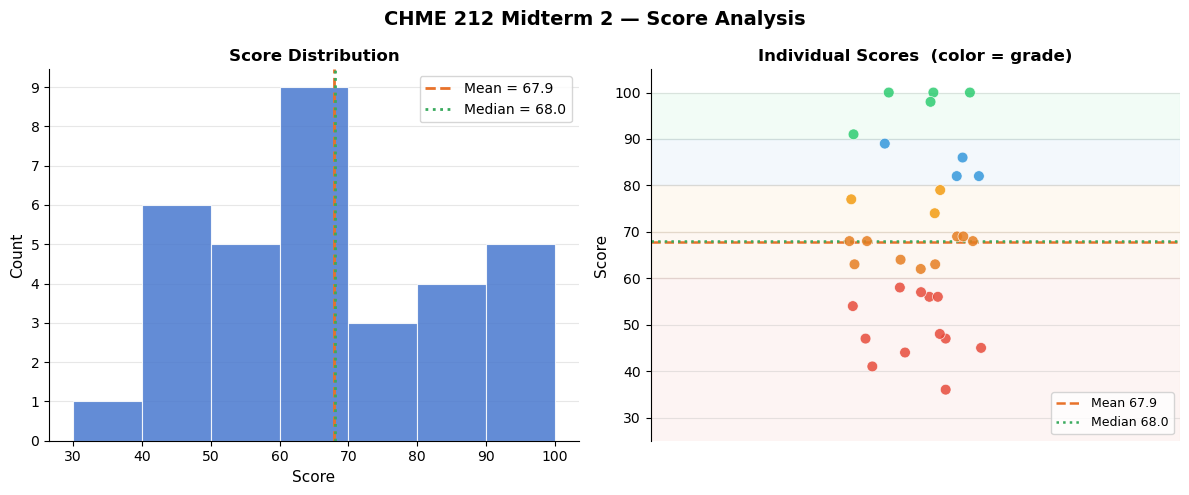

In [2]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.array([100, 89, 63, 77, 82, 100, 56, 47, 57, 68,
                   69, 68, 86, 91, 36, 41, 69, 62, 100, 44,
                   54, 47, 56, 74, 98, 58, 45, 82, 48, 63,
                   79, 64, 68])

n      = len(scores)
mean   = np.mean(scores)
median = np.median(scores)

def letter(s):
    if s >= 90: return 'A'
    elif s >= 80: return 'B'
    elif s >= 70: return 'C'
    elif s >= 60: return 'D'
    else: return 'F'

BLUE   = '#4878CF'
ORANGE = '#E8722A'
GREEN  = '#3aaa5e'
grade_colors = {'A': '#2ecc71', 'B': '#3498db', 'C': '#f39c12', 'D': '#e67e22', 'F': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("CHME 212 Midterm 2 — Score Analysis", fontsize=14, fontweight='bold')

# ── 1. Histogram ────────────────────────────────
ax1 = axes[0]
bins = np.arange(30, 105, 10)
ax1.hist(scores, bins=bins, color=BLUE, edgecolor='white', linewidth=0.8, alpha=0.85, zorder=2)
ax1.axvline(mean,   color=ORANGE, linewidth=2, linestyle='--', label=f'Mean = {mean:.1f}')
ax1.axvline(median, color=GREEN,  linewidth=2, linestyle=':',  label=f'Median = {median:.1f}')
for spine in ['top', 'right']: ax1.spines[spine].set_visible(False)
ax1.set_xlabel('Score', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xticks(bins)
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.grid(axis='y', alpha=0.3, zorder=1)

# ── 2. Individual scores (strip plot) ───────────
ax2 = axes[1]
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.15, 0.15, n)
dot_colors = [grade_colors[letter(s)] for s in scores]
ax2.scatter(jitter, scores, c=dot_colors, s=60, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3)
ax2.axhline(mean,   color=ORANGE, linewidth=1.8, linestyle='--', label=f'Mean {mean:.1f}')
ax2.axhline(median, color=GREEN,  linewidth=1.8, linestyle=':',  label=f'Median {median:.1f}')
for lo_b, hi_b, col in [(90, 100, '#2ecc71'), (80, 90, '#3498db'), (70, 80, '#f39c12'),
                         (60, 70,  '#e67e22'), (0,  60, '#e74c3c')]:
    ax2.axhspan(lo_b, hi_b, alpha=0.06, color=col)
ax2.set_xlim(-0.6, 0.6)
ax2.set_ylim(25, 105)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Individual Scores  (color = grade)', fontsize=12, fontweight='bold')
ax2.set_xticks([])
ax2.legend(fontsize=9, loc='lower right')
for spine in ['top', 'right', 'bottom']: ax2.spines[spine].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('midterm2_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()